<a href="https://colab.research.google.com/github/thanhungoc2552006-debug/MoE-SmartHome/blob/main/notebooks/01_aruba_data_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import pandas as pd

records = []

DATA_PATH = '/content/drive/MyDrive/Project_MoE/DATASET/aruba.txt'
with open(DATA_PATH, "r") as f:
    for line in f:
        parts = line.strip().split()

        if len(parts) < 4:
            continue

        date = parts[0]
        time = parts[1]
        sensor = parts[2]
        value = parts[3]

        activity = None
        marker = None

        if len(parts) >= 6:
            activity = parts[4]
            marker = parts[5]

        records.append({
            "date": date,
            "time": time,
            "sensor": sensor,
            "value": value,
            "activity": activity,
            "marker": marker
        })

df = pd.DataFrame(records)

df.head(15)

,date,time,sensor,value,activity,marker
0,2010-11-04,00:03:50.209589,M003,ON,Sleeping,begin
1,2010-11-04,00:03:57.399391,M003,OFF,None,None
2,2010-11-04,00:15:08.984841,T002,21.5,None,None
3,2010-11-04,00:30:19.185547,T003,21,None,None
4,2010-11-04,00:30:19.385336,T004,21,None,None
5,2010-11-04,00:35:22.24587,T005,20.5,None,None
6,2010-11-04,00:40:25.428962,T005,21,None,None
7,2010-11-04,00:45:28.658171,T005,20.5,None,None
8,2010-11-04,01:05:42.269469,T001,20,None,None
9,2010-11-04,01:15:48.936777,T002,21,None,None


In [17]:
import numpy as np
import pandas as pd

df = df.copy()
df["source_order"] = np.arange(len(df))

df["timestamp_text"] = (
    df["date"].astype("string").str.strip()
    + " "
    + df["time"].astype("string").str.strip()
)

# Hỗ trợ cả HH:MM:SS.%f và HH:MM:SS
df["timestamp"] = pd.to_datetime(
    df["timestamp_text"],
    format="mixed",
    errors="coerce"
)

invalid_mask = df["timestamp"].isna()

print("Số event:", len(df))
print("Kiểu timestamp:", df["timestamp"].dtype)
print("Invalid timestamps:", invalid_mask.sum())
print(
    "Chronological order:",
    df["timestamp"].dropna().is_monotonic_increasing
)
print(
    "Time range:",
    df["timestamp"].min(),
    "→",
    df["timestamp"].max()
)

if invalid_mask.any():
    display(
        df.loc[
            invalid_mask,
            ["date", "time", "sensor", "value"]
        ]
    )

assert invalid_mask.sum() == 0, "Vẫn còn timestamp không hợp lệ"

Số event: 1719558
Kiểu timestamp: datetime64[ns]
Invalid timestamps: 0
Chronological order: False
Time range: 2010-11-04 00:03:50.209589 → 2011-06-11 23:58:10.004834


Raw shape: (1719558, 9)
Time range: 2010-11-04 00:03:50.209589 → 2011-06-11 23:58:10.004834
Invalid timestamps: 0
Chronological order before cleaning: False

Duplicate rows cần loại: 6425
Tổng rows tham gia duplicate: 12850

Block size: 6425
First block index: 1564862 → 1571286
Second block index: 1571287 → 1577711
Duplicate positions contiguous: True
Two blocks identical: True

Before cleaning: 1719558
After cleaning: 1713133
Removed: 6425
Remaining duplicates: 0
Chronological order after cleaning: True

Event kinds:


,events
event_kind,
ambient_sensor,1713128
pseudo_event,5



Ambient sensor types:


,events
sensor_type,
M,1589887
T,116459
D,6782



Pseudo events: 5


,source_order,timestamp,sensor,value,activity,marker,event_kind,potential_label_leakage
1523044,1523044,2011-05-17 11:40:03.013619,LEAVEHOME,180,None,None,pseudo_event,True
1523584,1523584,2011-05-17 14:58:04.907136,LEAVEHOME,300,None,None,pseudo_event,True
1526729,1526729,2011-05-17 18:31:56.044148,LEAVEHOME,300,None,None,pseudo_event,True
1530032,1530032,2011-05-18 12:22:23.315366,LEAVEHOME,300,None,None,pseudo_event,True
1530061,1530061,2011-05-18 14:12:13.738946,ENTERHOME,6592,None,None,pseudo_event,True



Unknown events: 0

Missing values:


,count,percent
date,0,0.00
time,0,0.00
sensor,0,0.00
value,0,0.00
activity,1700253,99.25
marker,1700253,99.25
source_order,0,0.00
timestamp_text,0,0.00
timestamp,0,0.00
event_kind,0,0.00



Activity audit:


marker,begin,end,difference
activity,,,
Relax,2907,2907,0
Meal_Preparation,1596,1596,0
Enter_Home,427,427,0
Leave_Home,427,427,0
Sleeping,398,398,0
Eating,255,255,0
Work,171,171,0
Bed_to_Toilet,156,156,0
Wash_Dishes,64,64,0


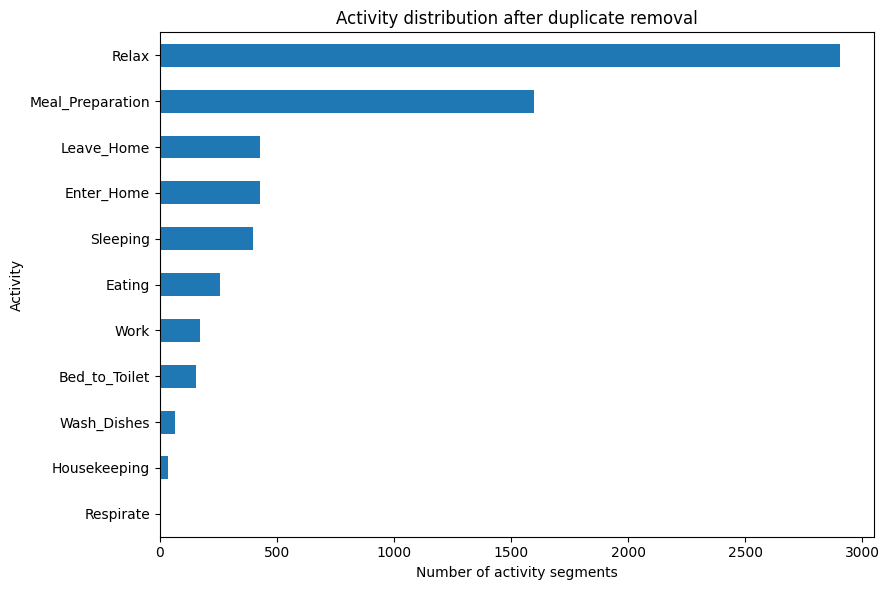

In [19]:
# DATA AUDIT — Aruba dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Kiểm tra tổng quan
# --------------------------------------------------

print("Raw shape:", df.shape)
print(
    "Time range:",
    df["timestamp"].min(),
    "→",
    df["timestamp"].max()
)
print("Invalid timestamps:", df["timestamp"].isna().sum())
print(
    "Chronological order before cleaning:",
    df["timestamp"].is_monotonic_increasing
)

# --------------------------------------------------
# 2. Kiểm tra duplicate trên dữ liệu gốc
# Không dùng source_order, timestamp_text hoặc sensor_type
# --------------------------------------------------

data_columns = [
    "date",
    "time",
    "sensor",
    "value",
    "activity",
    "marker",
]

duplicate_extra_mask = df.duplicated(
    subset=data_columns,
    keep="first"
)

duplicate_all_mask = df.duplicated(
    subset=data_columns,
    keep=False
)

n_duplicate_extra = int(duplicate_extra_mask.sum())
n_duplicate_all = int(duplicate_all_mask.sum())

print("\nDuplicate rows cần loại:", n_duplicate_extra)
print("Tổng rows tham gia duplicate:", n_duplicate_all)

# --------------------------------------------------
# 3. Xác nhận duplicate là hai block liên tiếp
# --------------------------------------------------

duplicate_positions = np.flatnonzero(
    duplicate_extra_mask.to_numpy()
)

block_verified = False

if len(duplicate_positions) > 0:
    block_size = len(duplicate_positions)

    is_contiguous = np.all(
        np.diff(duplicate_positions) == 1
    )

    second_start = duplicate_positions[0]
    first_start = second_start - block_size

    first_block = (
        df.iloc[first_start:second_start][data_columns]
        .reset_index(drop=True)
    )

    second_block = (
        df.iloc[
            second_start:second_start + block_size
        ][data_columns]
        .reset_index(drop=True)
    )

    block_verified = (
        is_contiguous
        and first_start >= 0
        and first_block.equals(second_block)
    )

    print("\nBlock size:", block_size)
    print(
        "First block index:",
        first_start,
        "→",
        second_start - 1
    )
    print(
        "Second block index:",
        second_start,
        "→",
        second_start + block_size - 1
    )
    print("Duplicate positions contiguous:", is_contiguous)
    print("Two blocks identical:", block_verified)

    assert block_verified, (
        "Duplicate chưa được xác nhận là một block lặp liên tiếp"
    )

# --------------------------------------------------
# 4. Tạo DataFrame sạch
# Giữ nguyên df để truy vết
# --------------------------------------------------

df_clean = (
    df.loc[~duplicate_extra_mask]
    .copy()
    .reset_index(drop=True)
)

remaining_duplicates = df_clean.duplicated(
    subset=data_columns,
    keep="first"
).sum()

print("\nBefore cleaning:", len(df))
print("After cleaning:", len(df_clean))
print("Removed:", len(df) - len(df_clean))
print("Remaining duplicates:", remaining_duplicates)
print(
    "Chronological order after cleaning:",
    df_clean["timestamp"].is_monotonic_increasing
)

# --------------------------------------------------
# 5. Phân loại ambient sensors và pseudo events
# --------------------------------------------------

sensor_text = (
    df_clean["sensor"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Ambient sensor chính thức: Mxxx, Dxxx, Txxx
ambient_mask = sensor_text.str.fullmatch(
    r"[MDT]\d{3}",
    na=False
)

# Unusual/pseudo events đã xác minh trong raw data
pseudo_mask = sensor_text.isin([
    "LEAVEHOME",
    "ENTERHOME",
])

# Các giá trị không thuộc hai nhóm đã biết
unknown_mask = ~(ambient_mask | pseudo_mask)

# Phân loại event nhưng giữ nguyên cột sensor gốc
df_clean["event_kind"] = "unknown"
df_clean.loc[
    ambient_mask,
    "event_kind"
] = "ambient_sensor"

df_clean.loc[
    pseudo_mask,
    "event_kind"
] = "pseudo_event"

# Sensor type dùng cho thống kê
df_clean["sensor_type"] = pd.Series(
    pd.NA,
    index=df_clean.index,
    dtype="string",
)

df_clean.loc[
    ambient_mask,
    "sensor_type"
] = sensor_text.loc[
    ambient_mask
].str[0]

df_clean.loc[
    pseudo_mask,
    "sensor_type"
] = "PSEUDO"

# Hai pseudo event có tên gần như trùng target activity,
# vì vậy có nguy cơ gây label leakage nếu đưa vào model.
df_clean["potential_label_leakage"] = pseudo_mask

print("\nEvent kinds:")
display(
    df_clean["event_kind"]
    .value_counts()
    .rename("events")
    .to_frame()
)

print("\nAmbient sensor types:")
display(
    df_clean.loc[
        ambient_mask,
        "sensor_type"
    ]
    .value_counts()
    .rename("events")
    .to_frame()
)

pseudo_events = df_clean.loc[
    pseudo_mask,
    [
        "source_order",
        "timestamp",
        "sensor",
        "value",
        "activity",
        "marker",
        "event_kind",
        "potential_label_leakage",
    ],
]

print("\nPseudo events:", len(pseudo_events))
display(pseudo_events)

unknown_events = df_clean.loc[
    unknown_mask,
    [
        "source_order",
        "timestamp",
        "sensor",
        "value",
        "activity",
        "marker",
    ],
]

print("\nUnknown events:", len(unknown_events))

if not unknown_events.empty:
    display(unknown_events)

assert len(pseudo_events) == 5, (
    "Số pseudo events khác kết quả audit dự kiến"
)

assert len(unknown_events) == 0, (
    "Có event chưa được phân loại"
)

# --------------------------------------------------
# 6. Missing-value audit trên dữ liệu sạch
# --------------------------------------------------

missing_report = pd.DataFrame({
    "count": df_clean.isna().sum(),
    "percent": (
        df_clean.isna().mean() * 100
    ).round(2),
})

print("\nMissing values:")
display(missing_report)

# --------------------------------------------------
# 7. Activity audit trên dữ liệu sạch
# --------------------------------------------------

activity_audit = pd.crosstab(
    df_clean["activity"],
    df_clean["marker"],
).reindex(
    columns=["begin", "end"],
    fill_value=0,
)

activity_audit["difference"] = (
    activity_audit["begin"]
    - activity_audit["end"]
)

print("\nActivity audit:")
display(
    activity_audit.sort_values(
        "begin",
        ascending=False,
    )
)

activity_audit["begin"].sort_values().plot.barh(
    figsize=(9, 6),
    title="Activity distribution after duplicate removal",
)

plt.xlabel("Number of activity segments")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()